
Steps for Initial Setup -

    Chose Pyspark kernel in Jupyter Notebook.
    Verify if SparkContext is available
    Load the dataset in HDFS or check the path of pre-loaded data in HDFS which is /gldata/Churn.csv and /gldata/Churntest.csv If you want to check the data, access it through Hue- HDFS browser.
    Learn how to work with Spark Dataframe, Pandas Dataframe and Spark ML Pipeline.

Steps for Project

    Create and Check Spark Context for Pyspark shell.
    Load necessary libraries
    Check the informtion provided about data.
    Import the data files provided from HDFS (Churn.csv and Churntest.csv).
    Display the data in Spark Dataframe. ( Note:: In pyspark, dataframe index the rows from 0 instead of 1)
    Do data pre-processing required.( Hint - We have some variables which should be of categorical datatype but they are of type integer. Convert them)
    Do exploratory data analysis. 7.1 - Describe the data using describe function and state your insights. 7.2 - Create Histogram for Day minutes spent by customers for churn=0 and 1 values. 7.3 - Create count plots for Number of customers opt voicemail plan with Churn values. 7.4 - Create count plots for International Plan opt by customer with Churn values. 7.5 - Plot Areawise churner and non-churner. 7.6 - Get correlation matrix using corr() function.
    Get correlation between Predicting Variable and independent variable and state your insights. (Now that we want to predict which customer is going to churn, let’s see what columns might be interesting for our prediction.One way is to find the correlation between "Churn" and each of the other columns.This will show us which other columns might predict "Churn" the best.)
    Applying Machine Learning Model 9.1 - Import necessary libraries 9.2 - Create vectors of all indepandant variables (Hint - use VectorAssembler) 9.3 - Apply Decision Tree Classifier using dependent and independent variables. 9.4 - Create pipeline to build the classifier. 9.5 - Use startified sampling to get a sample of data. 9.6 - Split the data into train and test dataset. 9.7 - Make predictions and validate your model by calculating accuracy score. 9.8 - Calculate recall and precision score. 9.9 - Test the model using test data and calculate accuracy, recall and precision. 9.10- Repeat steps from 9.3 to 9.9 for Random-forest and Gradient-Boost Classifiers.
    State your insights and conclusions from the above analysis.

About the Data

The dataset is about telecom industry which tells about the number of customers who churned the service. It consists of 3333 observations having 21 variables. We have to predict which customer is going to churn the service.

Account.Length: how long account has been active.

VMail.Message: Number of voice mail messages send by the customer.

Day.Mins: Time spent on day calls.

Eve.Mins: Time spent on evening calls.

Night.Mins: Time spent on night calls.

Intl. Mins: Time spent on international calls.

Day.Calls: Number of day calls by customers.

Eve.Calls: Number of evening calls by customers.

Intl.Calls: Number of international calls.

Night.Calls: Number of night calls by customer.

Day.Charge: Charges of Day Calls.

Night.Charge: Charges of Night Calls.

Eve.Charge: Charges of evening Calls.

Intl.Charge: Charges of international calls.

VMail.Plan: Voice mail plan taken by the customer or not.

State: State in Area of study.

Phone: Phone number of the customer.

Area.Code: Area Code of customer.

Int.l.Plan: Does customer have international plan or not.

CustServ.Calls: Number of customer service calls by customer.

Churn : Customers who churned the telecom service or who doesn’t(0=“Churner”, 1=“Non-Churner”)


# PySpark  Churn

This notebook installs PySpark, starts a Spark session, loads **Churn.csv**, does quick EDA, and builds a simple ML pipeline.

**How to use:**
1) Run the install cell
2) Start Spark
3) Choose a data loading option (upload to Colab or mount Drive)
4) Run EDA and the ML pipeline


In [ ]:
# import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.sql.window import Window
from pyspark.ml.feature import Imputer, StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
import re

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.feature import VectorAssembler
from sklearn.ensemble import GradientBoostingClassifier
from pyspark.sql.functions import when

In [ ]:
# Install PySpark (includes a compatible Java runtime)
!pip install -q pyspark
print('PySpark installed.')

PySpark installed.


In [ ]:
# Start Spark
from pyspark.sql import SparkSession
spark = (SparkSession.builder
         .appName('ColabSpark-Churn')
         .getOrCreate())
print('Spark version:', spark.version)

Spark version: 3.5.1


In [ ]:
# (Optional) Check Java availability
import shutil
print('java on PATH:', shutil.which('java'))

java on PATH: /usr/bin/java


In [ ]:
# Define file path
Path = "/content/drive/MyDrive/Spark/Churn.csv"  # if using Google Drive

use_drive = False  # set to True if using Google Drive path

In [ ]:
# Load CSV into Spark DataFrame
df = spark.read.csv(Path, header=True, inferSchema=True)

In [ ]:
# Show first 5 rows
df.show(5)

+-------------+------------+-------+-------+---------+--------+-------------+-----+--------+---------+--------+---------+--------+---------+----------+-----------+---------+----------+-----+--------+--------+
|AccountLength|VMailMessage|DayMins|EveMins|NightMins|IntlMins|CustServCalls|Churn|IntlPlan|VMailPlan|DayCalls|DayCharge|EveCalls|EveCharge|NightCalls|NightCharge|IntlCalls|IntlCharge|State|AreaCode|   Phone|
+-------------+------------+-------+-------+---------+--------+-------------+-----+--------+---------+--------+---------+--------+---------+----------+-----------+---------+----------+-----+--------+--------+
|          128|          25|  265.1|  197.4|    244.7|    10.0|            1|    0|       0|        1|     110|    45.07|      99|    16.78|        91|      11.01|        3|       2.7|   KS|     415|382-4657|
|          107|          26|  161.6|  195.5|    254.4|    13.7|            1|    0|       0|        1|     123|    27.47|     103|    16.62|       103|      11.45| 

**Data Preprocessing**

In [ ]:
# 2 Basic Audits
def columns_by_type(df):
    num_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, (T.IntegerType, T.LongType, T.FloatType, T.DoubleType, T.DecimalType, T.ShortType))]
    str_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, (T.StringType,))]
    bool_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, (T.BooleanType,))]
    date_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, (T.DateType, T.TimestampType))]
    return num_cols, str_cols, bool_cols, date_cols

num_cols, str_cols, bool_cols, date_cols = columns_by_type(df)

print("\nNumeric columns:", num_cols)
print("String columns :", str_cols)
print("Boolean cols  :", bool_cols)
print("Date/Time cols:", date_cols)

# Null counts per column
nulls_df = df.select([
    F.count(F.when(F.col(c).isNull() | F.isnan(c) | (F.col(c) == ""), c)).alias(c) if c in num_cols
    else F.count(F.when(F.col(c).isNull() | (F.trim(F.col(c)) == ""), c)).alias(c)
    for c in df.columns
])


Numeric columns: ['AccountLength', 'VMailMessage', 'DayMins', 'EveMins', 'NightMins', 'IntlMins', 'CustServCalls', 'Churn', 'IntlPlan', 'VMailPlan', 'DayCalls', 'DayCharge', 'EveCalls', 'EveCharge', 'NightCalls', 'NightCharge', 'IntlCalls', 'IntlCharge', 'AreaCode']
String columns : ['State', 'Phone']
Boolean cols  : []
Date/Time cols: []


In [ ]:
# missing values
nulls_df.show(truncate=False)

+-------------+------------+-------+-------+---------+--------+-------------+-----+--------+---------+--------+---------+--------+---------+----------+-----------+---------+----------+-----+--------+-----+
|AccountLength|VMailMessage|DayMins|EveMins|NightMins|IntlMins|CustServCalls|Churn|IntlPlan|VMailPlan|DayCalls|DayCharge|EveCalls|EveCharge|NightCalls|NightCharge|IntlCalls|IntlCharge|State|AreaCode|Phone|
+-------------+------------+-------+-------+---------+--------+-------------+-----+--------+---------+--------+---------+--------+---------+----------+-----------+---------+----------+-----+--------+-----+
|0            |0           |0      |0      |0        |0       |0            |0    |0       |0        |0       |0        |0       |0        |0         |0          |0        |0         |0    |0       |0    |
+-------------+------------+-------+-------+---------+--------+-------------+-----+--------+---------+--------+---------+--------+---------+----------+-----------+---------+---

In [ ]:
# Sort nulls by counts in descending order
nulls_df_sorted = nulls_df.orderBy([F.col(c).desc() for c in nulls_df.columns])
nulls_df_sorted.show(truncate=False)

+-------------+------------+-------+-------+---------+--------+-------------+-----+--------+---------+--------+---------+--------+---------+----------+-----------+---------+----------+-----+--------+-----+
|AccountLength|VMailMessage|DayMins|EveMins|NightMins|IntlMins|CustServCalls|Churn|IntlPlan|VMailPlan|DayCalls|DayCharge|EveCalls|EveCharge|NightCalls|NightCharge|IntlCalls|IntlCharge|State|AreaCode|Phone|
+-------------+------------+-------+-------+---------+--------+-------------+-----+--------+---------+--------+---------+--------+---------+----------+-----------+---------+----------+-----+--------+-----+
|0            |0           |0      |0      |0        |0       |0            |0    |0       |0        |0       |0        |0       |0        |0         |0          |0        |0         |0    |0       |0    |
+-------------+------------+-------+-------+---------+--------+-------------+-----+--------+---------+--------+---------+--------+---------+----------+-----------+---------+---

In [ ]:
# Duplicates
dup_count =df.count() -df.dropDuplicates().count()
print(f"\nDuplicates found: {dup_count:,}")


Duplicates found: 0


As shown above, no missing values nor duplicates were recorded in the dataset

In [ ]:
# String Cleaning (trim, collapse whitespace, set empty -> null)
def clean_string_columns(df, str_cols):
    cleaned = df
    for c in str_cols:
        cleaned = cleaned.withColumn(c, F.trim(F.regexp_replace(F.col(c), r"\s+", " ")))
        cleaned = cleaned.withColumn(c, F.when(F.col(c) == "", F.lit(None)).otherwise(F.col(c)))
    return cleaned

df = clean_string_columns(df, str_cols)

# Recompute null stats after string cleanup
num_cols, str_cols, bool_cols, date_cols = columns_by_type(df)
print("\n--- NULLS PER COLUMN (after string cleanup) ---")
df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show(truncate=False)


--- NULLS PER COLUMN (after string cleanup) ---
+-------------+------------+-------+-------+---------+--------+-------------+-----+--------+---------+--------+---------+--------+---------+----------+-----------+---------+----------+-----+--------+-----+
|AccountLength|VMailMessage|DayMins|EveMins|NightMins|IntlMins|CustServCalls|Churn|IntlPlan|VMailPlan|DayCalls|DayCharge|EveCalls|EveCharge|NightCalls|NightCharge|IntlCalls|IntlCharge|State|AreaCode|Phone|
+-------------+------------+-------+-------+---------+--------+-------------+-----+--------+---------+--------+---------+--------+---------+----------+-----------+---------+----------+-----+--------+-----+
|0            |0           |0      |0      |0        |0       |0            |0    |0       |0        |0       |0        |0       |0        |0         |0          |0        |0         |0    |0       |0    |
+-------------+------------+-------+-------+---------+--------+-------------+-----+--------+---------+--------+---------+------

In [ ]:
# Drop columns with excessive missingness / low variance
# Thresholds (tune as needed)
missing_drop_threshold = 0.60  # drop column if >60% missing
nrows = df.count()

# Missing fraction per column
miss_frac = df.select([
    (F.count(F.when(F.col(c).isNull(), c)) / F.lit(nrows)).alias(c) for c in df.columns
]).collect()[0].asDict()

cols_to_drop_missing = [c for c, frac in miss_frac.items() if frac is not None and frac > missing_drop_threshold]
if cols_to_drop_missing:
    print("\nDropping high-missing columns:", cols_to_drop_missing)
    df = df.drop(*cols_to_drop_missing)

# Low variance (constant) columns
def constant_columns(df):
    stats = df.select([F.countDistinct(F.col(c)).alias(c) for c in df.columns]).collect()[0].asDict()
    return [c for c, ndist in stats.items() if ndist == 1]

const_cols = constant_columns(df)
if const_cols:
    print("\nDropping constant columns:", const_cols)
    df = df.drop(*const_cols)

# Refresh column type lists
num_cols, str_cols, bool_cols, date_cols = columns_by_type(df)

In [ ]:
#  Handle Booleans as Ints , Parse Dates (if any)
for c in bool_cols:
    df = df.withColumn(c, F.col(c).cast(T.IntegerType()))
num_cols, str_cols, bool_cols, date_cols = columns_by_type(df)

# If you know date-like string columns, parse them here:
# date_like = ["SignupDate", "LastActive"]  # example
# for c in set(date_like).intersection(set(df.columns)):
#     df = df.withColumn(c, F.to_timestamp(F.col(c)))
# date_cols = date_cols + list(set(date_like).intersection(set(df.columns)))

In [ ]:
# Impute missing values
# Numeric: median (fallback to mean if Spark doesn't support median; change strategy='mean')
# Categorical: fill 'Unknown'
# Numeric imputer
impute_num_cols = [c for c in num_cols if c != "churn"] if "churn" else num_cols
imputer = None
if impute_num_cols:
    imputer = Imputer(
        inputCols=impute_num_cols,
        outputCols=[f"{c}__imputed" for c in impute_num_cols],
        strategy="median"  # use "mean" if median is not supported by spark version
    )

In [ ]:
# 11) Outlier Check (IQR) for numeric cols (pre-imputation columns)
def iqr_bounds(df, col):
    q = df.approxQuantile(col, [0.25, 0.75], 0.01)
    if len(q) < 2:
        return None, None
    q1, q3 = q
    iqr = q3 - q1
    return (q1 - 1.5*iqr, q3 + 1.5*iqr)

print("\n--- OUTLIER REPORT (numeric) ---")
for c in impute_num_cols:
    lb, ub = iqr_bounds(df, c)
    if lb is None:
        continue
    out_cnt = df.filter((F.col(c) < lb) | (F.col(c) > ub)).count()
    if out_cnt > 0:
        print(f"{c}: {out_cnt:,} potential outliers (IQR bounds [{lb:.3f}, {ub:.3f}])")
    else:
        print(f"{c}: no strong outliers by IQR")


--- OUTLIER REPORT (numeric) ---
AccountLength: 17 potential outliers (IQR bounds [-8.000, 208.000])
VMailMessage: 13 potential outliers (IQR bounds [-27.000, 45.000])
DayMins: 24 potential outliers (IQR bounds [32.850, 325.250])
EveMins: 25 potential outliers (IQR bounds [62.400, 336.800])
NightMins: 29 potential outliers (IQR bounds [63.750, 336.150])
IntlMins: 48 potential outliers (IQR bounds [3.000, 17.400])
CustServCalls: 267 potential outliers (IQR bounds [-0.500, 3.500])
Churn: 483 potential outliers (IQR bounds [0.000, 0.000])
IntlPlan: 323 potential outliers (IQR bounds [0.000, 0.000])
VMailPlan: no strong outliers by IQR
DayCalls: 23 potential outliers (IQR bounds [46.500, 154.500])
DayCharge: 24 potential outliers (IQR bounds [5.600, 55.280])
EveCalls: 19 potential outliers (IQR bounds [45.500, 153.500])
EveCharge: 25 potential outliers (IQR bounds [5.305, 28.625])
NightCalls: 18 potential outliers (IQR bounds [45.500, 153.500])
NightCharge: 29 potential outliers (IQR boun

**Outliers Report**

Usage variables are right-skewed. Minutes/charges and call counts (Day/Eve/Night, Intl*) show upper-tail outliers (e.g., DayMins > 325.25, CustServCalls > 3.5).

IQR negatives aren’t real. Negative lower bounds (e.g., -8.0) are an artifact of IQR; minutes/calls can’t be <0—treat these as upper-tail only.

Redundant flags. Charges mirror minutes (e.g., DayMins & DayCharge), so both flag together.

Key variables with notable outliers

CustServCalls (267 > 3.5): Strong signal of dissatisfaction; keep (don’t drop), but cap/winsorize extreme values (e.g., at 95th–99th pct).

IntlCalls (78 > 10.5), IntlMins/IntlCharge (48 each): Heavy international usage; cap at high percentiles or log1p transform.

Day/Eve/Night Mins (24–29 each) & Charges (24–29 each): High users; pick either minutes or charges (avoid double counting), then winsorize/log.

Day/Eve/Night Calls (18–23 each): High frequency; winsorize or bin (e.g., 0–50, 51–100, >100).

VMailMessage (13 > 45): Heavy voicemail users; cap or bin.

AccountLength (17 > 208): Long-tenure tails; cap or use robust scaling.

AreaCode (840 outside [397.5, 425.5]): Treat as categorical (one-hot/embedding), not numeric; outlier notion doesn’t apply.

Churn, IntlPlan: Binary labels/features—ignore IQR outlier flags.

VMailPlan: No strong outliers—no action needed.

In [ ]:
features = ['AccountLength', 'VMailMessage', 'DayMins', 'EveMins', 'NightMins', 'IntlMins', 'CustServCalls', 'IntlPlan', 'VMailPlan', 'DayCalls', 'DayCharge', 'EveCalls', 'EveCharge', 'NightCalls', 'NightCharge', 'IntlCalls', 'IntlCharge', 'State', 'AreaCode']

In [ ]:
target = ['Churn']

In [ ]:
cleaned_cols = sorted(set(df.columns) - set(const_cols) - set(cols_to_drop_missing or []))
print("\nColumns retained for modeling artifacts (pre-encoded):")
print(cleaned_cols)


Columns retained for modeling artifacts (pre-encoded):
['AccountLength', 'AreaCode', 'Churn', 'CustServCalls', 'DayCalls', 'DayCharge', 'DayMins', 'EveCalls', 'EveCharge', 'EveMins', 'IntlCalls', 'IntlCharge', 'IntlMins', 'IntlPlan', 'NightCalls', 'NightCharge', 'NightMins', 'Phone', 'State', 'VMailMessage', 'VMailPlan']


In [ ]:
cat_cols = ['Churn', 'IntlPlan', 'VMailPlan']

In [ ]:
df.write.mode("overwrite").parquet("/tmp/churn_clean_features.parquet")

In [ ]:
# Save cleaned raw (pre-encoded) version as Parquet/CSV for inspection
(df
 .coalesce(1)  # optional: single file (careful with very large data)
 .write.mode("overwrite")
 .option("header", True)
 .csv("/tmp/churn_clean_raw_csv"))

print("\ndf written to:")
print(" - /tmp/churn_clean_features.parquet  (model-ready features)")
print(" - /tmp/churn_clean_raw_csv          (cleaned raw CSV folder)")


df written to:
 - /tmp/churn_clean_features.parquet  (model-ready features)
 - /tmp/churn_clean_raw_csv          (cleaned raw CSV folder)


In [ ]:
# Drop columns
df = df.drop("State", "AreaCode", "Phone")

In [ ]:
# Numeric summary
# Update impute_num_cols after dropping columns
num_cols, str_cols, bool_cols, date_cols = columns_by_type(df)
impute_num_cols = [c for c in num_cols if c != "Churn"] if "Churn" else num_cols

if impute_num_cols:
    df.select([F.col(c).cast("double").alias(c) for c in impute_num_cols]).summary().show()
print(df)

+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+
|summary|     AccountLength|      VMailMessage|           DayMins|           EveMins|         NightMins|          IntlMins|     CustServCalls|          IntlPlan|          VMailPlan|          DayCalls|         DayCharge|          EveCalls|         EveCharge|        NightCalls|      NightCharge|         IntlCalls|        IntlCharge|
+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+
|

In [ ]:
# Drop irrelevant columns
df = df.drop("State", "AreaCode","State_idx","AreaCode_idx", "Phone")

# Exploratory Data Analysis

In [ ]:
# Describe data
df.describe().show()

+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+-------------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+
|summary|     AccountLength|      VMailMessage|           DayMins|           EveMins|         NightMins|          IntlMins|     CustServCalls|              Churn|          IntlPlan|          VMailPlan|          DayCalls|         DayCharge|          EveCalls|         EveCharge|        NightCalls|      NightCharge|         IntlCalls|        IntlCharge|
+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+-------------------+------------------+------------------+------------------+------------------+-----------------

Completeness: 3,333 records across all fields with no missing values after cleaning. • Churn rate: Mean of 0.145 (14.5%) customers churned. • Plan uptake: Internal Plan 9.7%, Voice Mail Plan (27.7%) of customers. • Usage (mins): Averages ≈ Day 179.8, Evening 201.0, Night 200.9, International 10.24; SDs (50-54 for Day/Eve/Night) show moderate spread with heavy users at the top end. Charges align with per-minute tariffs: o Day ≈ 0.17/min (30.56÷179.78) o Evening is 0.085/min (17.08 ÷ 200.98) o Night ≈ 0.045/min (9.04÷200.87). International is 0.27/min (2.76 ÷ 10.24). Call counts: ~100 calls in each Day/Eve/Night period on average; international calls (4.48). Customer service contacts: Mean 1.56 (0-9) — high variance suggests a small group of contacts support frequently. • Voicemail usage: voice mail message means 8.1, SD 13.7 (many zeros; highly skewed).
 Max minutes/charges indicate a minority of very heavy users; note some IQR lower bounds < 0 are artefacts (actual mins/calls can't be negative). Net: dataset is complete, churn is 15%, plan adoption is modest, usage and charges behave consistently with tariff rates, and a skewed tail of heavy users exists (notably in service calls and voicemail).


**Descriptive Analaysis Report**


**A function to draw a histogram + boxplot for every numeric column on the same scale (shared x-axis + identical bin edges) for both Pandas or a PySpark DataFrame**

In [ ]:
def plot_hist_box_all_numeric(
    df,
    numeric_cols=None,
    bins=30,
    sample=None,
    figsize=(8, 4),
    save_dir=None,
    dpi=120,
):
    """
    Plot a histogram and a horizontal boxplot for each numeric column,
    all using the SAME x-scale and SAME histogram bin edges.

    Parameters
    ----------
    df : pandas.DataFrame or pyspark.sql.DataFrame
    numeric_cols : list[str] | None
        If None, auto-detect numeric columns.
    bins : int | array-like
        Number of bins (int) or explicit bin edges (array).
    sample : int | None
        For Spark DataFrames only: number of rows to sample before toPandas().
        If None, converts all rows (be careful with very large data).
    figsize : (float, float)
        Size of a single column's figure (hist+box together). Height is doubled internally.
    save_dir : str | Path | None
        If provided, saves each column's figure as a PNG in this directory.
    dpi : int
        DPI for saving figures.

    Returns
    -------
    list of matplotlib.figure.Figure
        One figure per numeric column.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    # Detect Spark vs pandas without importing pyspark unless needed
    is_spark = df.__class__.__module__.startswith("pyspark.")

    if is_spark:
        # Work with Spark lazily; only pull needed numeric columns
        from pyspark.sql import types as T

        if numeric_cols is None:
            numeric_cols = [
                f.name for f in df.schema.fields
                if isinstance(
                    f.dataType,
                    (T.IntegerType, T.LongType, T.FloatType, T.DoubleType, T.ShortType, T.DecimalType),
                )
            ]

        if not numeric_cols:
            raise ValueError("No numeric columns found in the Spark DataFrame.")

        sdf = df.select(*numeric_cols)
        row_count = sdf.count()  # needed to compute fraction if sampling
        if sample is not None and row_count > 0:
            frac = min(1.0, float(sample) / float(row_count))
            pdf = sdf.sample(withReplacement=False, fraction=frac, seed=42).toPandas()
        else:
            pdf = sdf.toPandas()

    else:
        # pandas path
        import pandas as pd
        if numeric_cols is None:
            numeric_cols = df.select_dtypes(include="number").columns.tolist()
        if not numeric_cols:
            raise ValueError("No numeric columns found in the pandas DataFrame.")
        pdf = df[numeric_cols].copy()

    # Drop all-null numeric columns
    numeric_cols = [c for c in numeric_cols if c in pdf.columns and pdf[c].notna().any()]
    if not numeric_cols:
        raise ValueError("All numeric columns are empty after dropping nulls.")

    # Compute global min/max across all numeric columns to enforce SAME scale
    arrays = [pdf[c].dropna().to_numpy() for c in numeric_cols]
    all_vals = np.concatenate([a for a in arrays if a.size > 0])
    if all_vals.size == 0:
        raise ValueError("No numeric data to plot after dropping NaNs.")

    global_min, global_max = np.nanmin(all_vals), np.nanmax(all_vals)
    if np.isclose(global_min, global_max):
        # avoid zero-width axis if constant data
        global_min -= 0.5
        global_max += 0.5

    # Build shared bin edges
    if isinstance(bins, int):
        bin_edges = np.linspace(global_min, global_max, bins + 1)
    else:
        bin_edges = np.asarray(bins)

    # Plot each column (hist + box) sharing same x-limits/binning
    figs = []
    for col in numeric_cols:
        series = pdf[col].dropna().to_numpy()
        if series.size == 0:
            continue

        fig, axs = plt.subplots(2, 1, figsize=(figsize[0], figsize[1] * 2), constrained_layout=True)

        # Histogram
        axs[0].hist(series, bins=bin_edges)
        axs[0].set_xlim(global_min, global_max)
        axs[0].set_title(f"{col} — Histogram")
        axs[0].set_ylabel("Count")

        # Boxplot (horizontal)
        axs[1].boxplot(series, vert=False, whis=1.5, showfliers=True)
        axs[1].set_xlim(global_min, global_max)
        axs[1].set_xlabel(col)
        axs[1].set_title(f"{col} — Boxplot")

        if save_dir:
            import os
            os.makedirs(save_dir, exist_ok=True)
            fig.savefig(os.path.join(save_dir, f"{col}_hist_box.png"), dpi=dpi)

        figs.append(fig)

    return figs

[<Figure size 800x800 with 2 Axes>]

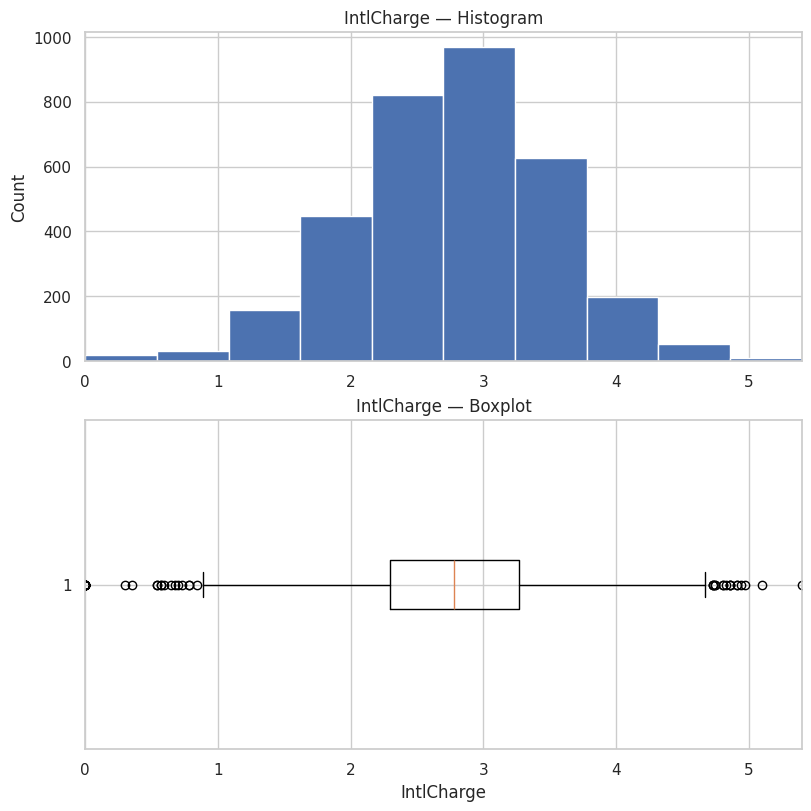

In [ ]:
# Visualize International Charges with histogram and a boxplot
plot_hist_box_all_numeric(df, numeric_cols=['IntlCharge'], sample=10000, bins=10)

International Chargers with Histogram and Box Plot
Key stats
•	n: 3,333
•	Mean / SD: 2.765 / 0.754
•	Min / Max: 0.0 / 5.4
•	Rate check: IntlCharge / IntlMins ≈ $0.27/min.
Distribution & outliers
•	Shape is unimodal, mildly right-skewed; bulk around 2.0–3.8, median ≈ 3.0.
•	IQR bounds: < 0.815 or > 4.695.
•	48 cases (~1.4%) are outliers:
o	Low tail: near-zero charges → little/no international usage.
o	High tail: > 4.7, genuine heavy international callers.
Data quality
•	No negatives; zeros are valid (no intl calls).
•	Collinearity: IntlCharge and IntlMins carry the same signal; keeping both duplicates information.
Business interpretation
•	Most customers have moderate international spend.
•	A small, high-spend segment drives the upper tail—prime targets for international plan/discount offers; low-spend users unlikely to convert.


[<Figure size 800x800 with 2 Axes>]

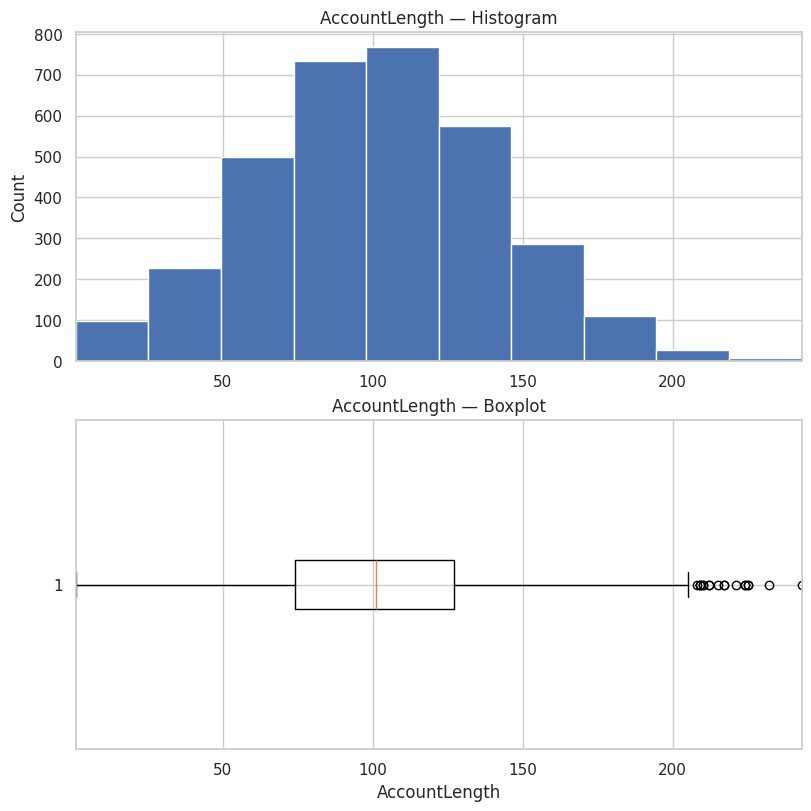

In [ ]:
# Visualize  Account Length with histogram and a boxplot
plot_hist_box_all_numeric(df, numeric_cols=['AccountLength'], sample=10000, bins=10)

[<Figure size 800x800 with 2 Axes>]

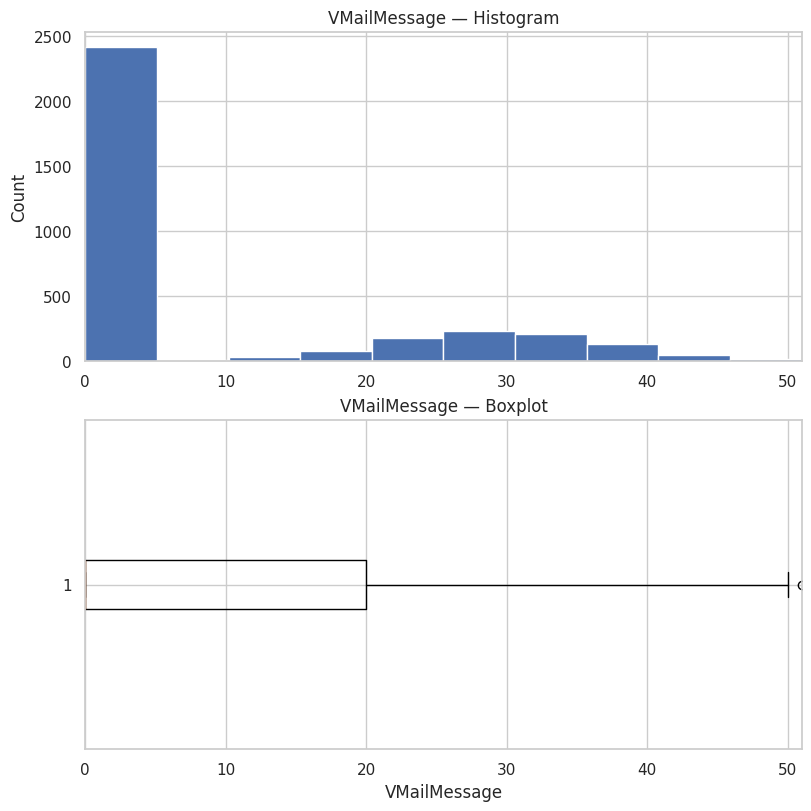

In [ ]:
# Visualize VMail Messages with histogram and a boxplot
plot_hist_box_all_numeric(df, numeric_cols=['VMailMessage'], sample=10000, bins=10)

Voice Mail Messages
Distribution: Heavily zero-inflated and right-skewed. A large majority have 0–5 messages; a small group ranges up to 50.
Centre & spread: Median near 0; mean = 8.1 with high variance, reflecting a long upper tail.
Outliers: Values > ~45 appear as upper-tail outliers (few but extreme).
Interpretation: Two segments—non-users (most customers) and active voicemail users (minority).


[<Figure size 800x800 with 2 Axes>]

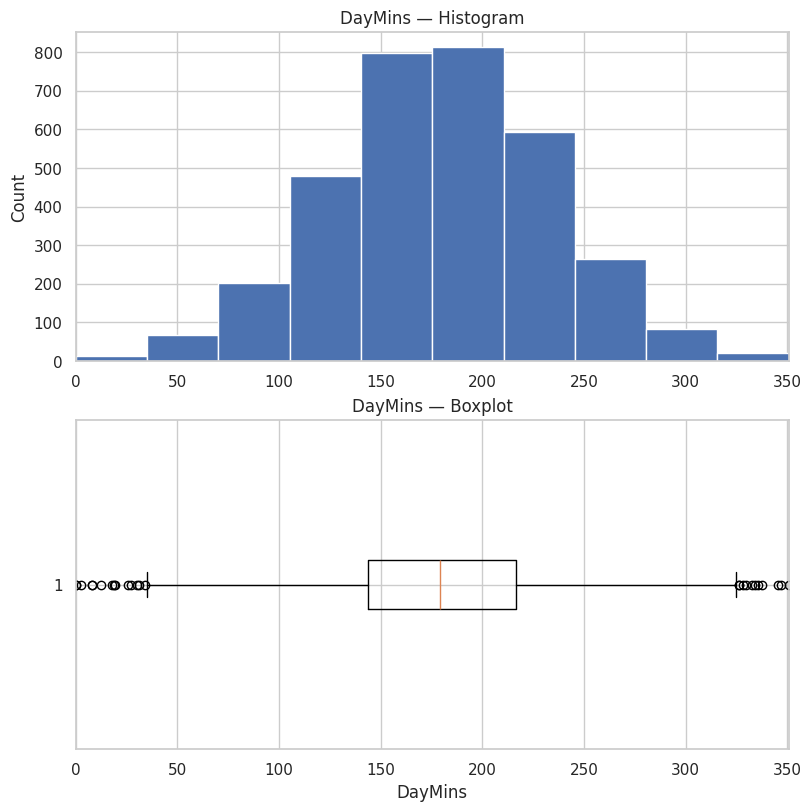

In [ ]:
# Visualize Day Minutes with histogram and a boxplot
plot_hist_box_all_numeric(df, numeric_cols=['DayMins'], sample=10000, bins=10)

Most customers spent between 130–230 minutes per day. Median sits around ~180–190 mins; the box (IQR) spans about ~150–210 mins. Values range from near 0 up to ~350 mins; prior summary showed mean ≈ 179.8 and SD ≈ 54.5. Outliers: A few low-use cases (< ~35 mins) and high-use cases (> ~325 mins) appear as dots on the boxplot—these are the heavy daytime callers. Takeaways: Typical usage is moderate; a small high-usage segment drives the upper tail and can materially affect averages and models.

[<Figure size 800x800 with 2 Axes>]

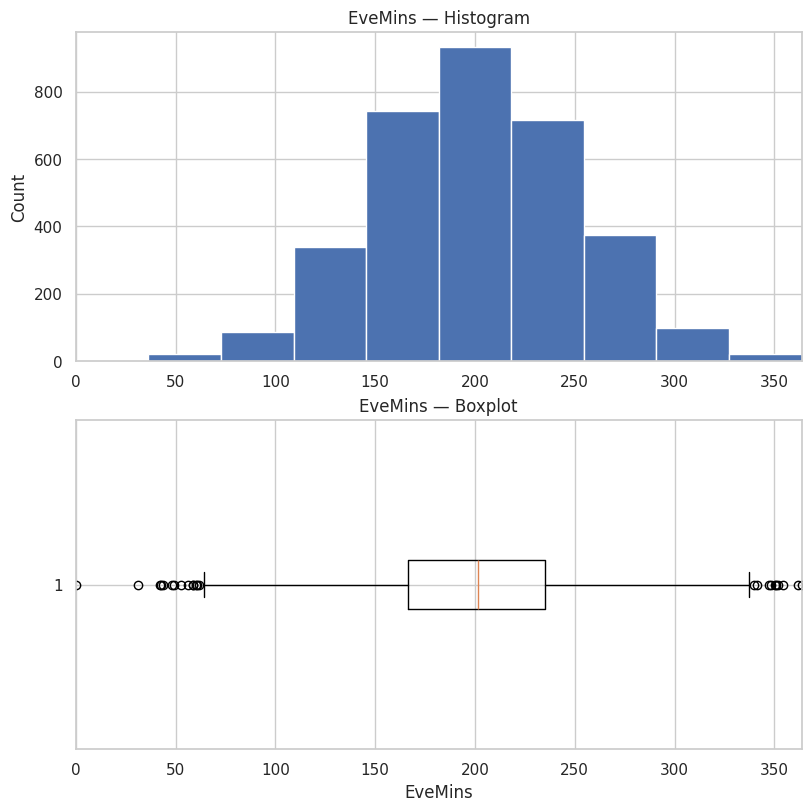

In [ ]:
# Visualize Evening Minutes with histogram and a boxplot
plot_hist_box_all_numeric(df, numeric_cols=['EveMins'], sample=10000, bins=10)

|


[<Figure size 800x800 with 2 Axes>]

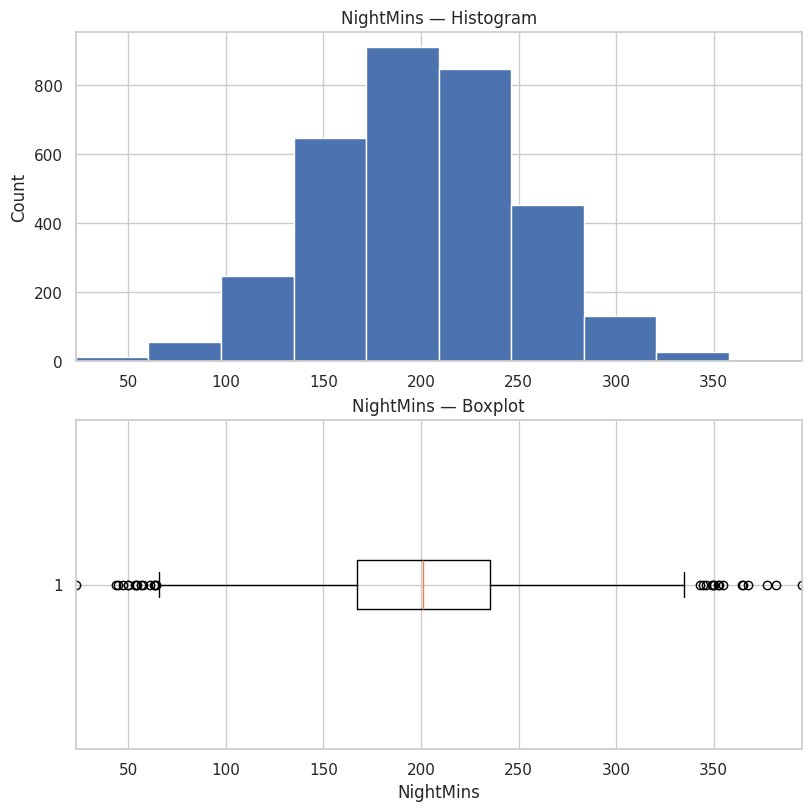

In [ ]:
# Visualize Night Minutes with histogram and a boxplot
plot_hist_box_all_numeric(df, numeric_cols=['NightMins'], sample=10000, bins=10)

Night Minutes
•	The shape is unimodal, near-symmetric with a slight right tail; density concentrated around 170–230 mins. Mean is 200.9 mins, standard deviation recorded 50.6; median = 200. Range is 3–395 mins.
•	Outliers (IQR): Below 63.8 and above 336.2; about 29 cases flagged, mostly high-usage night callers.
•	Most customers show moderate night usage; a small heavy-caller segment drives the upper tail


[<Figure size 800x800 with 2 Axes>]

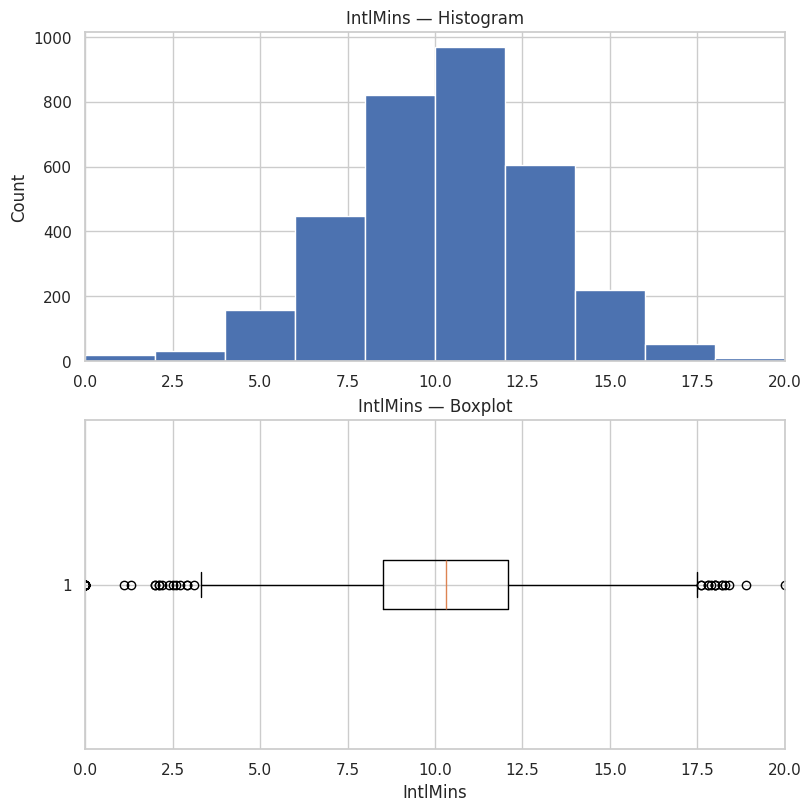

In [ ]:
# Visualize International Minutes with histogram and a boxplot
plot_hist_box_all_numeric(df, numeric_cols=['IntlMins'], sample=10000, bins=10)

[<Figure size 800x800 with 2 Axes>]

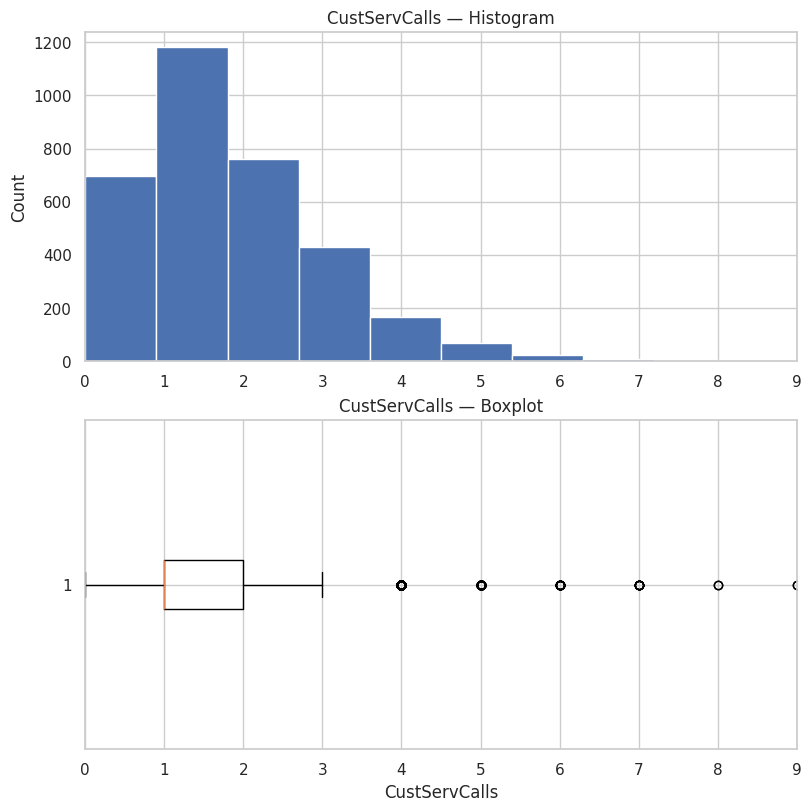

In [ ]:
# Visualize Custumer Service Calls with histogram and a boxplot
plot_hist_box_all_numeric(df, numeric_cols=['CustServCalls'], sample=10000, bins=10)

[<Figure size 800x800 with 2 Axes>]

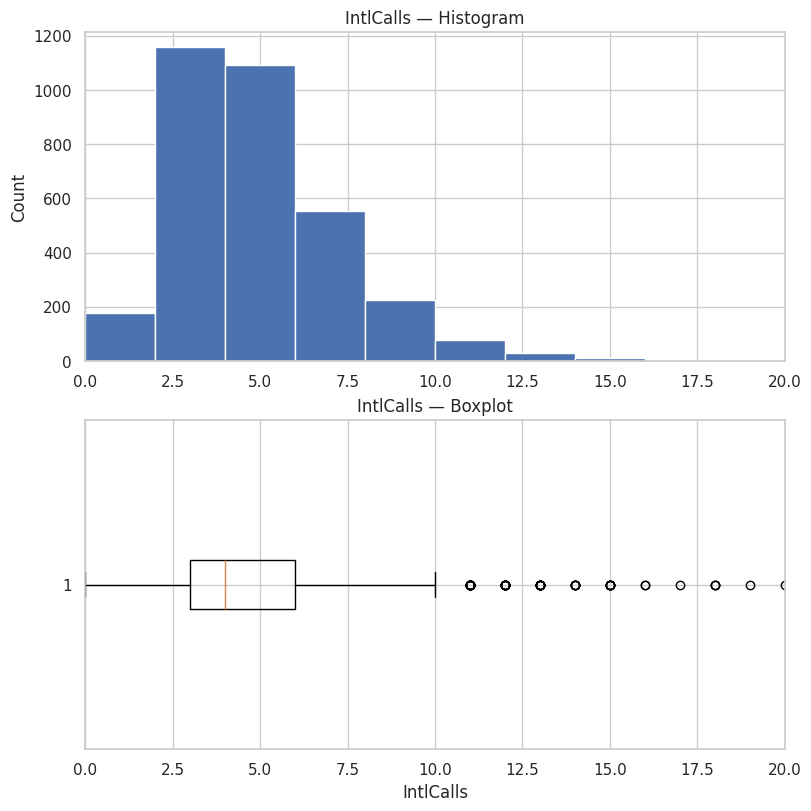

In [ ]:
# Visualize International Calls with histogram and a boxplot
plot_hist_box_all_numeric(df, numeric_cols=['IntlCalls'], sample=10000, bins=10)

[<Figure size 800x800 with 2 Axes>]

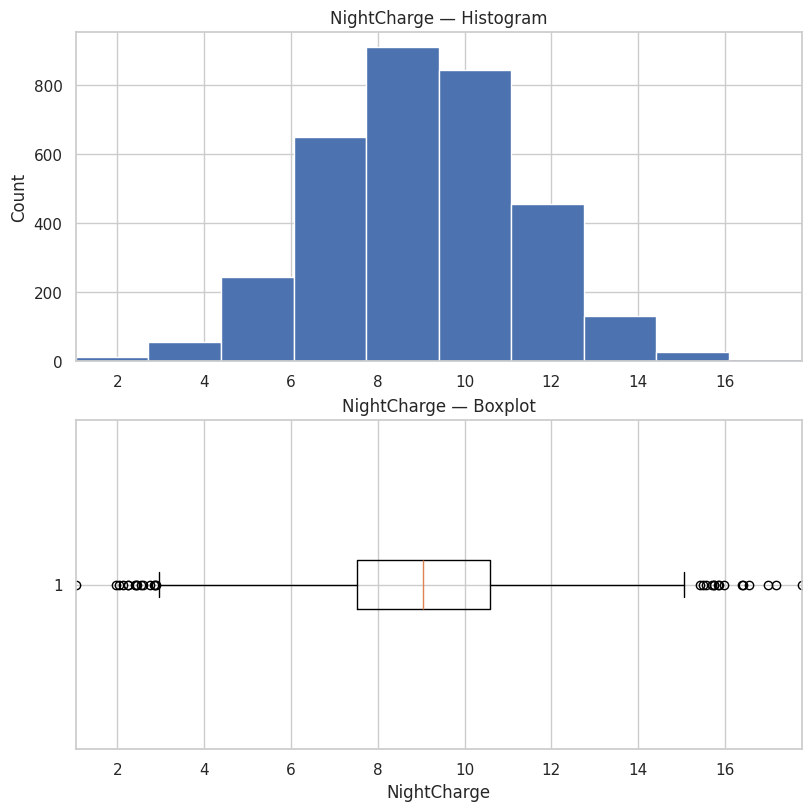

In [ ]:
# Visualize Night Charges with histogram and a boxplot
plot_hist_box_all_numeric(df, numeric_cols=['NightCharge'], sample=10000, bins=10)

[<Figure size 800x800 with 2 Axes>]

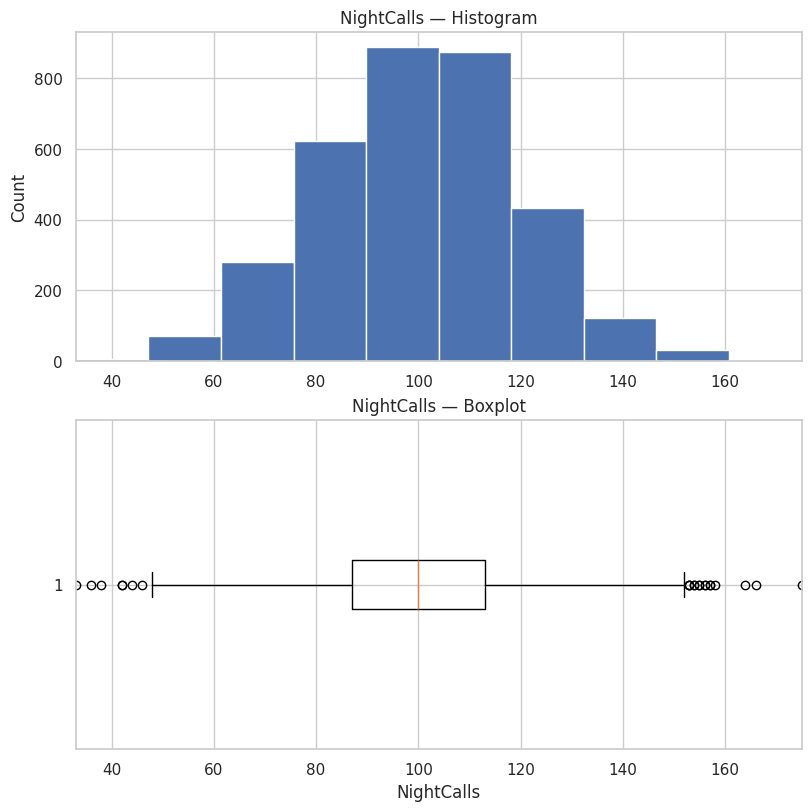

In [ ]:
# Visualize Night Calls with histogram and a boxplot
plot_hist_box_all_numeric(df, numeric_cols=['NightCalls'], sample=10000, bins=10)

[<Figure size 800x800 with 2 Axes>]

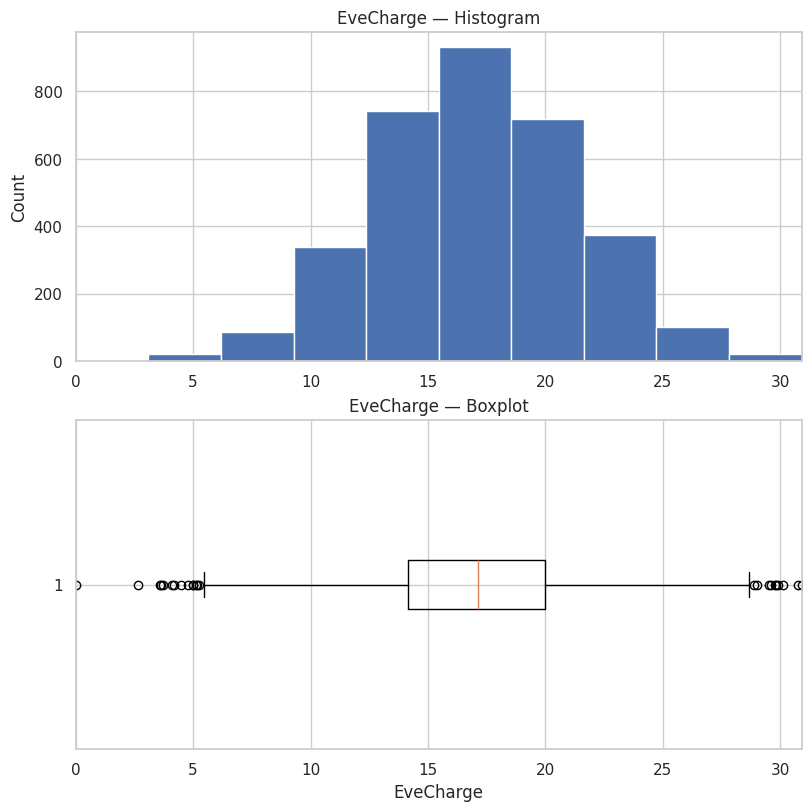

In [ ]:
# Visualize Evening Charges with histogram and a boxplot
plot_hist_box_all_numeric(df, numeric_cols=['EveCharge'], sample=10000, bins=10)

[<Figure size 800x800 with 2 Axes>]

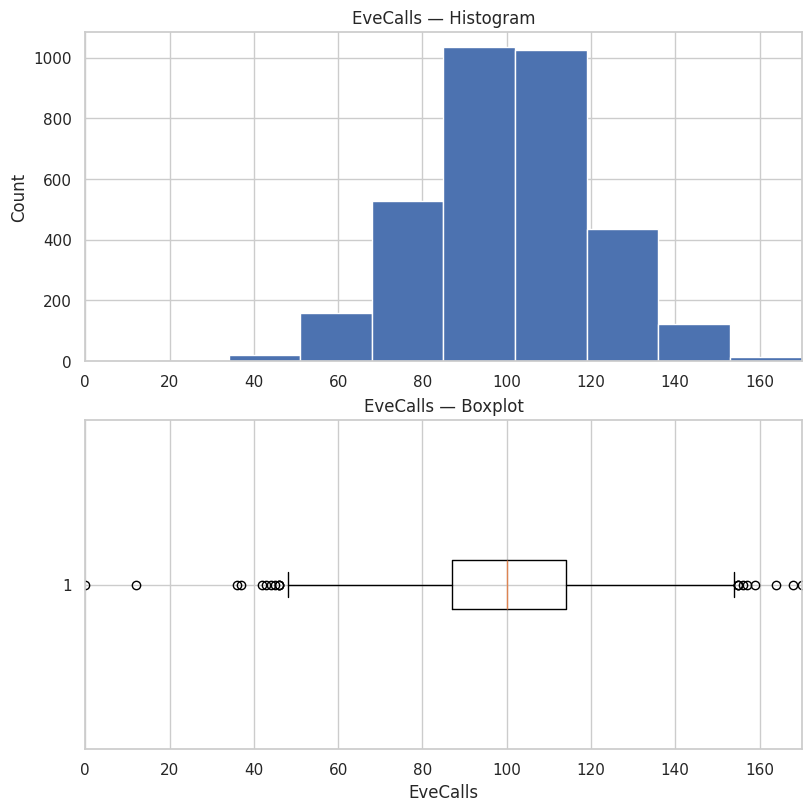

In [ ]:
# Visualize Evening Calls with histogram and a boxplot
plot_hist_box_all_numeric(df, numeric_cols=['EveCalls'], sample=10000, bins=10)

[<Figure size 800x800 with 2 Axes>]

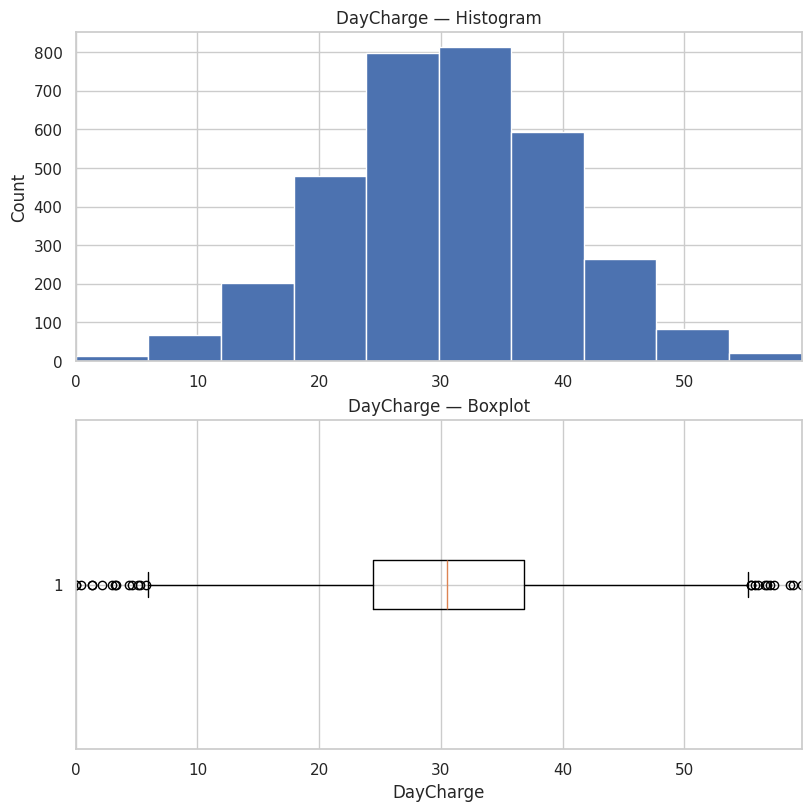

In [ ]:
# Visualize DayCharge with histogram and a boxplot
plot_hist_box_all_numeric(df, numeric_cols=['DayCharge'], sample=10000, bins=10)

[<Figure size 800x800 with 2 Axes>]

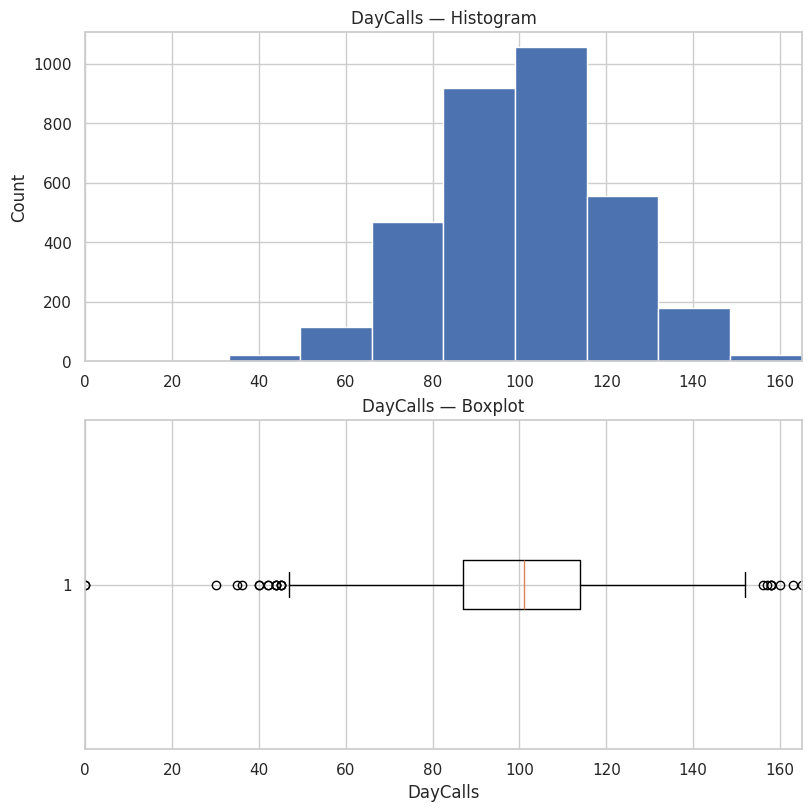

In [ ]:
# Visualize Day Calls with a Histogram and a Boxplot
plot_hist_box_all_numeric(df, numeric_cols=['DayCalls'], sample=10000, bins=10)

[<Figure size 800x800 with 2 Axes>]

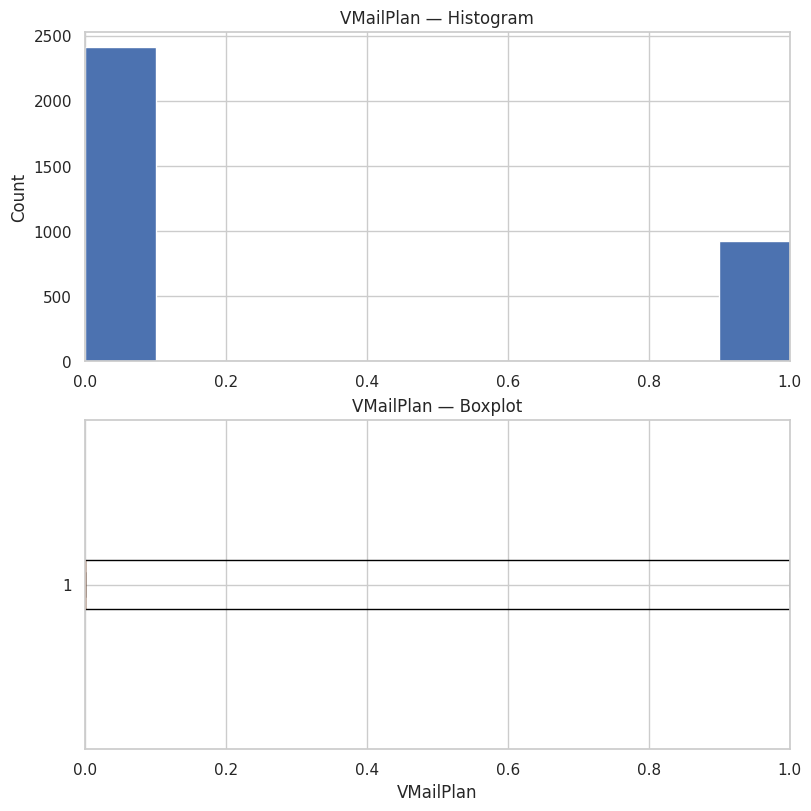

In [ ]:
# Visualize Voice Mail Plan with a Histogram and a Box Plot
plot_hist_box_all_numeric(df, numeric_cols=['VMailPlan'], sample=10000, bins=10)

[<Figure size 800x800 with 2 Axes>]

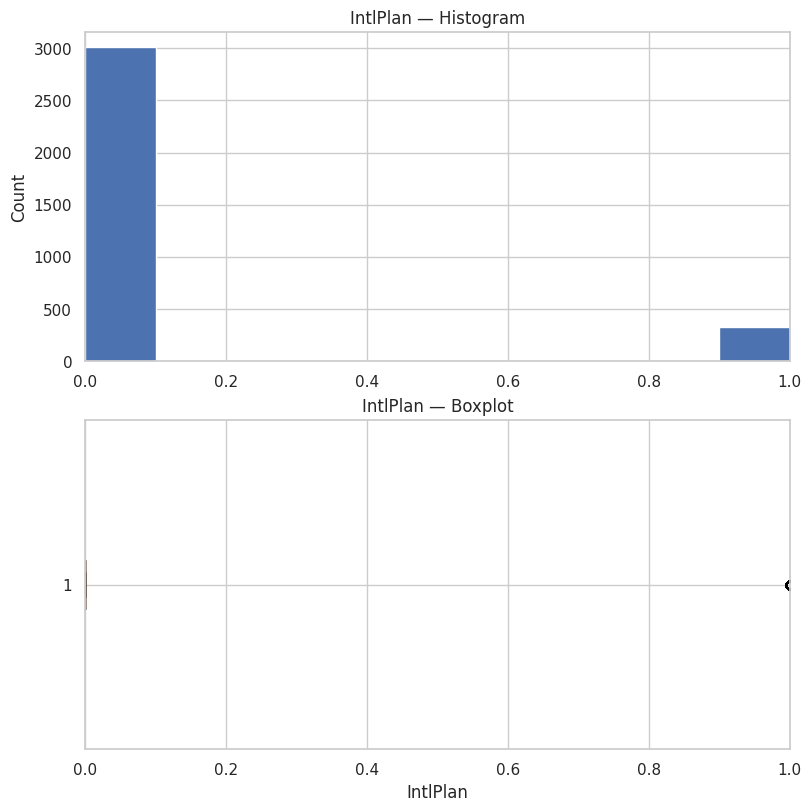

In [ ]:
# Visualize International Plan with a Histogram and a Boxplot
plot_hist_box_all_numeric(df, numeric_cols=['IntlPlan'], sample=10000, bins=10)

[<Figure size 800x800 with 2 Axes>]

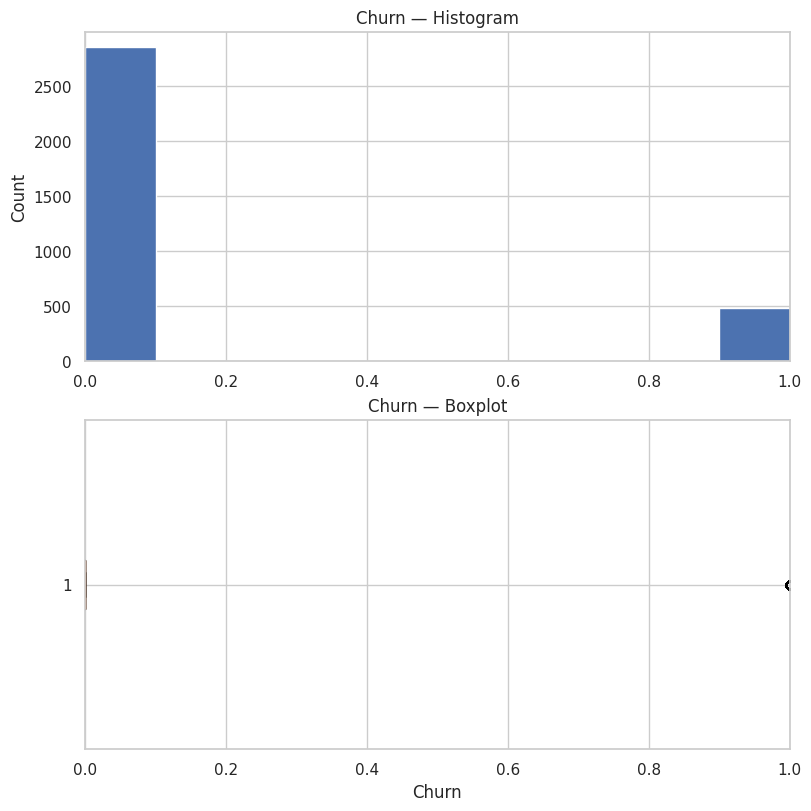

In [ ]:
# Visualize Churn with a Histogram and a Boxplot
plot_hist_box_all_numeric(df, numeric_cols=['Churn'], sample=10000, bins=10)

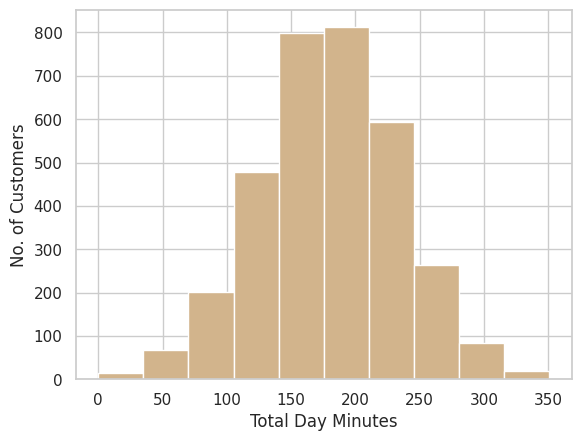

In [ ]:
# Convert the 'DayMins' column from Spark DataFrame to pandas Series for plotting
day_mins_data = df.select('DayMins').toPandas()['DayMins']

plt.hist(day_mins_data, bins= 10, facecolor= 'tan')
plt.xlabel('Total Day Minutes')
plt.ylabel('No. of Customers')
plt.show()

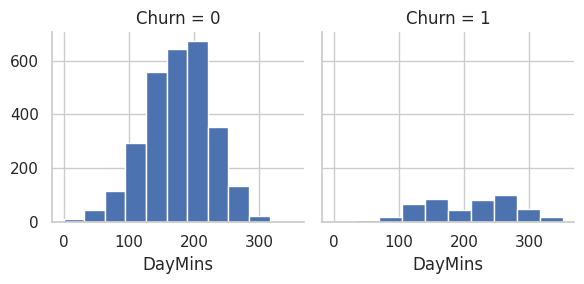

In [ ]:
# Convert necessary columns to pandas DataFrame for seaborn
churn_day_mins_data = df.select("DayMins", "Churn").toPandas()

g = sns.FacetGrid(churn_day_mins_data, col="Churn")
g.map(plt.hist, "DayMins")
plt.show()

Day Minutes Churn
Far fewer churners (right panel) than non-churners → strong imbalance (15% churn ).
•	Churn = 0: Tight cluster around 150–220 mins; fewer extremes.
•	Churn = 1: Distribution shifts right with more observations >200 mins and a longer tail up to 320+. Higher daytime usage appears positively associated with churn. Heavy daytime callers are over-represented among churners.


In [ ]:
# Number of customers opt voice mail plan
df.groupBy('VMailPlan').count().show()

+---------+-----+
|VMailPlan|count|
+---------+-----+
|        1|  922|
|        0| 2411|
+---------+-----+



We find that 2411 customers who didn't opt the voice mail plan and 922 customers who opted the voice mail plan.

In [ ]:
# Visualizing Number of customers opt voice mail plan

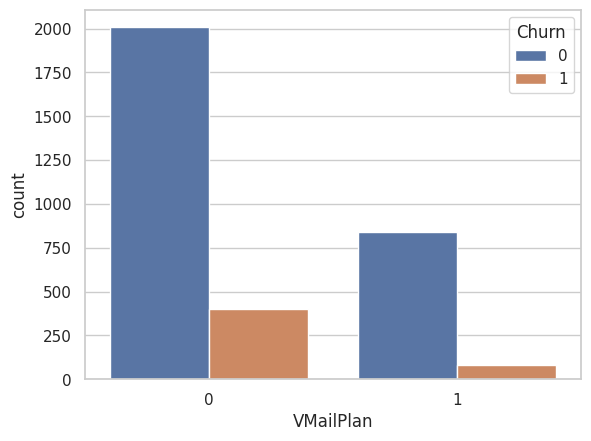

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert necessary columns to pandas DataFrame for seaborn
vmail_churn_data = df.select("VMailPlan", "Churn").toPandas()

sns.set(style="whitegrid", color_codes=True)
sns.countplot(x="VMailPlan", hue="Churn", data=vmail_churn_data)
plt.show()

In [ ]:
df.groupBy('IntlPlan').count().show()

+--------+-----+
|IntlPlan|count|
+--------+-----+
|       1|  323|
|       0| 3010|
+--------+-----+



We find that 3010 customer didn't opt international plan and 323 customers opt the international plan.

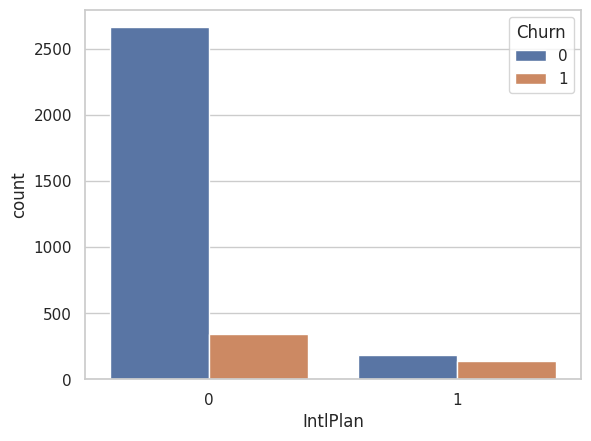

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert necessary columns to pandas DataFrame for seaborn
intl_churn_data = df.select("IntlPlan", "Churn").toPandas()

sns.set(style="whitegrid", color_codes=True)
sns.countplot(x="IntlPlan", hue="Churn", data=intl_churn_data)
plt.show()

**Areawise churner and non-churner**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert necessary columns to pandas DataFrame for seaborn
area_churn_data = df.select("AreaCode", "Churn").toPandas()

sns.set(style="whitegrid", color_codes=True)
sns.countplot(x="AreaCode", hue="Churn", data=area_churn_data)
plt.show()

Build a simple ML pipeline (example: Logistic Regression)
This assumes there is a **label** column named `Churn` (with values like Yes/No or 1/0). Adjust the `label_col` and feature handling as needed.

In [ ]:
# df['Churn'].dtype == 'integer':
# df['Churn'] = df['Churn'].map({1,0})

In [ ]:
# List feature variables
feature = df.columns
feature.remove('Churn')
print(feature)

['AccountLength', 'VMailMessage', 'DayMins', 'EveMins', 'NightMins', 'IntlMins', 'CustServCalls', 'IntlPlan', 'VMailPlan', 'DayCalls', 'DayCharge', 'EveCalls', 'EveCharge', 'NightCalls', 'NightCharge', 'IntlCalls', 'IntlCharge']


In [ ]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline

schema_dtypes = dict(df.dtypes)
label_col = "Churn"

# Initialize stages list
stages = []

if schema_dtypes.get(label_col, "").lower() == "string":
    label_indexer = StringIndexer(inputCol=label_col, outputCol="label", handleInvalid="keep")
    stages.append(label_indexer)
    base_df = df
else:
    # ensure a numeric 'label' column exists
    base_df = df.withColumnRenamed(label_col, "label")

# Feature columns = all except original label and derived 'label'
drop_cols = {label_col, "label"}
feature = [c for c in df.columns if c not in drop_cols]

In [ ]:
# Split features by type
cat_cols = [c for c, t in df.dtypes if c in feature and t.lower() == "string"]
num_cols = [c for c, t in df.dtypes if c in feature and t.lower() != "string"]

# Index + OneHot encode categoricals
indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in cat_cols]
encoders = OneHotEncoder(
    inputCols=[f"{c}_idx" for c in cat_cols],
    outputCols=[f"{c}_oh"  for c in cat_cols]
    # Removed dropLast=True to avoid feature importance mismatch
)
stages += indexers + [encoders]

assembler = VectorAssembler(
    inputCols=[*(f"{c}_oh" for c in cat_cols), *num_cols],
    outputCol="features",
    handleInvalid="keep"   # keep rows with nulls in numerics
)
stages.append(assembler)

# Train/test split (80/20)
train_df, test_df = base_df.randomSplit([0.8, 0.2], seed=42)

In [ ]:
# Models
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier

lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=100)
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label", maxDepth=10, seed=42)
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=200, seed=42)

# Build three pipelines (shared preprocessing + different estimator)
from pyspark.ml import Pipeline

pipe_lr = Pipeline(stages=stages + [lr])
pipe_dt = Pipeline(stages=stages + [dt])
pipe_rf = Pipeline(stages=stages + [rf])

# Fit & predict
model_lr = pipe_lr.fit(train_df)
pred_lr = model_lr.transform(test_df)

model_dt = pipe_dt.fit(train_df)
pred_dt = model_dt.transform(test_df)

model_rf = pipe_rf.fit(train_df)
pred_rf = model_rf.transform(test_df) # Add this line

In [ ]:
# Evaluation
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

def evaluate(pred_df, name="Model"):
    acc  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy").evaluate(pred_df)
    f1   = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1").evaluate(pred_df)
    prec = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision").evaluate(pred_df)
    rec  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall").evaluate(pred_df)

    print(f"\n=== {name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    # Confusion matrix
    print("Confusion Matrix (label x prediction):")
    (pred_df
     .groupBy("label", "prediction")
     .count()
     .orderBy("label", "prediction")
     .show(truncate=False))

evaluate(pred_lr, "Logistic Regression")


=== Logistic Regression ===
Accuracy : 0.8585
Precision: 0.8220
Recall   : 0.8585
F1-score : 0.8315
Confusion Matrix (label x prediction):
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|0    |0.0       |514  |
|0    |1.0       |19   |
|1    |0.0       |68   |
|1    |1.0       |14   |
+-----+----------+-----+



Model Evaluation with Logistic Regression
•	Overall accuracy looks high (85.9%) because the dataset is imbalanced (positives ≈ 13%).
•	The model is excellent at predicting non-churn (class 0) but poor at catching churners (class 1). The confusion matrix reveals that:
•	TN = 514, FP = 19, FN = 68, TP = 14 (N = 615).
•	Specificity (class-0 recall) = 514 / (514+19) = 96.4%, it rarely raises false alarms.
•	Sensitivity/Recall (class-1) = 14 / (14+68) = 17.1%, it misses most churners.
•	Precision (class-1) = 14 / (14+19) = 42.4%, when it predicts churn, it’s right ~42% of the time.
•	Balanced accuracy ≈ (96.4% + 17.1%) / 2 = 56.7% reveals the imbalance issue hidden by accuracy.


In [ ]:
evaluate(pred_dt, "Decision Tree")


=== Decision Tree ===
Accuracy : 0.9382
Precision: 0.9358
Recall   : 0.9382
F1-score : 0.9365
Confusion Matrix (label x prediction):
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|0    |0.0       |519  |
|0    |1.0       |14   |
|1    |0.0       |24   |
|1    |1.0       |58   |
+-----+----------+-----+



Model Evaluation with Decision Tree
•	TN=519, FP=14, FN=24, TP=58 (N=615)
•	Accuracy: 0.938 → (519+58)/615. High overall.
•	Positive-class precision (churn): 58/(58+14)=0.806 → when the model predicts churn, it’s right ~81%.
•	Positive-class recall (sensitivity): 58/(58+24)=0.707 → it finds ~71% of churners.
•	Specificity (non-churn recall): 519/(519+14)=0.974 → very few false alarms.
•	FPR: 14/(519+14)=2.6%; FNR: 24/(58+24)=29.3%.
•	Balanced accuracy: (0.707+0.974)/2 ≈ 0.841 (accounts for class imbalance).
•	F1 (positive class): ≈ 0.753 (harmonic mean of 0.806 precision & 0.707 recall).
•	Reported Precision/Recall/F1 ≈ 0.936 are weighted averages, dominated by the majority (non-churn) class.
•	The tree achieves high overall accuracy while maintaining low false positives and solid churn detection (recall ~71%).
•	Compared with a typical baseline logistic model (which often misses many churners), this tree substantially improves recall with acceptable precision—useful for retention targeting.
•	Only 24 churners were missed, while 14 customers were incorrectly flagged.


In [ ]:
evaluate(pred_rf, "Random Forest")


=== Random Forest ===
Accuracy : 0.9252
Precision: 0.9270
Recall   : 0.9252
F1-score : 0.9137
Confusion Matrix (label x prediction):
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|0    |0.0       |531  |
|0    |1.0       |2    |
|1    |0.0       |44   |
|1    |1.0       |38   |
+-----+----------+-----+



Model Evaluation with Random Forest

From the confusion matrix (True Negative (TN=531), False Positive (FP) =2, False Negative (FN) = 44, True Positive (TP) =38; Total ( N=615):
•	Accuracy: (531+38)/615 = 92.5% which is high overall.
•	Positive-class precision (churn): 38/(38+2) = 95.0%. When RF flags churn, it’s almost always right.
•	Positive-class recall (sensitivity): 38/(38+44) = 46.3%, half of churners.
•	Specificity (non-churn recall): 531/(531+2) = 99.6%, almost no false alarms.
•	FPR / FNR: 0.38% vs 53.7%.
•	Balanced accuracy: (0.996 + 0.463)/2 ≈ 73.0% (accounts for class imbalance).
•	F1 (positive class): ≈ 0.62; reported Precision/Recall/F1 (0.927/0.925/0.914) are weighted and dominated by the majority class. This means the model is very conservative: it protects against false positives (only 2) but misses a sizeable number of churners (44). To improve the model, we proceed with Gradient Booster

Model Evaluation with Gradient Booster


In [ ]:
# Gradient Booster Classification

In [ ]:
# Train Gradient-Boosted Trees ----
gbt = GBTClassifier(
    featuresCol="features",
    labelCol="label",
    maxDepth=5,
    maxIter=200,       # number of boosting stages
    stepSize=0.05,     # learning rate
    seed=42
)

# Build GBT pipeline (shared preprocessing + GBT estimator)
pipe_gbt = Pipeline(stages=stages + [gbt])

# Fit & predict
model_gbt = pipe_gbt.fit(train_df)
pred = model_gbt.transform(test_df).cache()

In [ ]:
# Metrics
acc_eval  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
prec_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
rec_eval  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")
f1_eval   = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
auc_eval  = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

acc  = acc_eval.evaluate(pred)
prec = prec_eval.evaluate(pred)
rec  = rec_eval.evaluate(pred)
f1   = f1_eval.evaluate(pred)
auc  = auc_eval.evaluate(pred)

print("=== Gradient Boosting (PySpark GBTClassifier) ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")
# Confusion Matrix in the same text layout
cm_df = (pred
         .groupBy("label", "prediction")
         .count()
         .orderBy("label", "prediction"))
cm = {(r['label'], r['prediction']): r['count'] for r in cm_df.collect()}

print("Confusion Matrix (label x prediction):")
print("|label|prediction|count|")
for lab in [0.0, 1.0]:
    for prd in [0.0, 1.0]:
        cnt = cm.get((lab, prd), 0)
        print(f"|{int(lab):<5}|{prd:<10}|{cnt:<5}|")

=== Gradient Boosting (PySpark GBTClassifier) ===
Accuracy : 0.9767
Precision: 0.9773
Recall   : 0.9767
F1-score : 0.9758
ROC AUC  : 0.9762
Confusion Matrix (label x prediction):
|label|prediction|count|
|0    |0.0       |593  |
|0    |1.0       |0    |
|1    |0.0       |16   |
|1    |1.0       |78   |


Model Evaluation with Gradient Booster
Overall performance is excellent (Accuracy 97.67%, AUC 0.9762), indicating strong rank-ordering and calibration potential. No false positives (FPR = 0%), i.e., all predicted positives are correct (Precision for class 1 = 100%). Minority-class recall: TPR ≈ 83.0% (78/94). The model missed 16 positives (FNR ≈ 17.0%), which drives the small gap in F1. Specificity for class 0 is 100% (593/593). Precision for class 0 ≈ : 97.4% (593/609).  Class balance is skewed (positives ≈ 13.7% of 687 samples). Weighted metrics, therefore, look slightly better than positive-class recall.
